In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

zip_file_path = '/content/drive/MyDrive/unlearning_project/ARTIFACTS/CIFAR-weights.zip'
destination_path = '/content/drive/MyDrive/unlearning_project/ARTIFACTS/'

# Create the destination directory if it doesn't exist
os.makedirs(destination_path, exist_ok=True)

# Unzip the file
!unzip -q "{zip_file_path}" -d "{destination_path}"

print(f"Successfully unzipped {zip_file_path} to {destination_path}")

unzip:  cannot find or open /content/drive/MyDrive/unlearning_project/ARTIFACTS/CIFAR-weights.zip, /content/drive/MyDrive/unlearning_project/ARTIFACTS/CIFAR-weights.zip.zip or /content/drive/MyDrive/unlearning_project/ARTIFACTS/CIFAR-weights.zip.ZIP.
Successfully unzipped /content/drive/MyDrive/unlearning_project/ARTIFACTS/CIFAR-weights.zip to /content/drive/MyDrive/unlearning_project/ARTIFACTS/


In [ ]:
import torchvision
c10  = torchvision.datasets.CIFAR10('/content/drive/MyDrive/unlearning_project/ARTIFACTS/data',  train=True, download=False)
c100 = torchvision.datasets.CIFAR100('/content/drive/MyDrive/unlearning_project/ARTIFACTS/data', train=True, download=False)



CIFAR-10:
  1 → automobile
  3 → cat
  5 → dog
CIFAR-100:
  0 → apple
  55 → otter
  34 → fox


In [ ]:
print("CIFAR-10:")
for i in [1, 3, 5]: print(f"  {i} → {c10.classes[i]}")

print("CIFAR-100:")
for i in [0, 55, 72]: print(f"  {i} → {c100.classes[i]}")

CIFAR-10:
  1 → automobile
  3 → cat
  5 → dog
CIFAR-100:
  0 → apple
  55 → otter
  72 → seal


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/unlearning_project/ARTIFACTS/ablation_combined_final.csv')
print(df[df['forget_cls']=='seal']['data_set'].value_counts())
# Should show CIFAR100 rows

data_set
CIFAR100    92
Name: count, dtype: int64


In [ ]:
# ============================================================
# ABLATION v2 — PS-PCGrad + Baselines (GA, Linear, PCGrad)
# Changes vs v1:
#   • Best-epoch tracking (saves best model mid-run)
#   • Append-safe CSV (multiple runs accumulate into one file)
#   • GA + Linear + PCGrad baselines included in CSV
#   • Tiny-budget structured sweep added (b=0.001, 0.003, 0.005)
#     to test whether structured collapse is due to hitting
#     concentrated important features
#   • 5 epochs throughout
#   • num_workers=0 to suppress multiprocessing warnings
# ============================================================

import os, csv, time, copy
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as tv_models
import numpy as np
from itertools import cycle
from torch.utils.data import DataLoader, Subset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# after dataset is loaded, pull num_classes automatically
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
# ── Root path — change only this one line ───────────────────
ROOT = '/content/drive/MyDrive/unlearning_project/ARTIFACTS'

# ── All paths derived from root ──────────────────────────────
RESNET_PATH  = f'{ROOT}/CIFAR-weights/resnet18_cifar100_ft.pth'
EFFNET_PATH  = f'{ROOT}/CIFAR-weights/efficientnet_cifar100_ft.pth'
CSV_PATH     = f'{ROOT}/ablation_all_results_100.csv'
# ── Change this to run a different forget class ──────────────
FORGET_CLASS = [0,55,72]  # apple
# or 55 (otter), 72 (rocket), [0, 55, 72] for multiclass
DATA_SET='CIFAR100'


CSV_COLUMNS = [
    'data_set','arch', 'forget_cls', 'method', 'budget_b', 'lambda', 'mask_mode',
    'epochs_run', 'best_epoch',
    'forget_acc', 'retain_acc', 'overall_acc',
    'baseline_forget', 'baseline_retain', 'baseline_overall',
    'forget_drop', 'retain_drop', 'score', 'time_s'
]


# ── Initialise CSV if it doesn't exist yet ──────────────────
def init_csv(path):
    if not os.path.exists(path):
        with open(path, 'w', newline='') as f:
            csv.DictWriter(f, fieldnames=CSV_COLUMNS).writeheader()
        print(f"✔ Created {path}")
    else:
        print(f"✔ Appending to existing {path}")


def append_csv(path, row):
    with open(path, 'a', newline='') as f:
        w = csv.DictWriter(f, fieldnames=CSV_COLUMNS)
        w.writerow(row)


# ============================================================
# TRANSFORMS & DATASETS
# ============================================================
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408),
                      (0.2675, 0.2565, 0.2761))
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408),
                      (0.2675, 0.2565, 0.2761))
])


dataset_class = getattr(torchvision.datasets, DATA_SET)

trainset      = dataset_class(f'{ROOT}/data', train=True,  download=True,  transform=train_transform)
testset       = dataset_class(f'{ROOT}/data', train=False, download=True,  transform=test_transform)
trainset_eval = dataset_class(f'{ROOT}/data', train=True,  download=False, transform=test_transform)
# num_workers=0 avoids the multiprocessing assertion error in notebooks
testloader  = DataLoader(testset,   batch_size=100, shuffle=False, num_workers=0)
trainloader = DataLoader(trainset,  batch_size=128, shuffle=True,  num_workers=0)
num_classes = len(trainset.classes)  # 100 for CIFAR-100
CLASS_NAMES = trainset.classes       # replaces CIFAR10_CLASSES list


# ============================================================
# HELPERS
# ============================================================
def evaluate(model, loader, device, forget_classes=None):
    model.eval()
    correct = total = fc = ft = rc = rt = 0
    if forget_classes is not None and isinstance(forget_classes, int):
        forget_classes = [forget_classes]
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            if isinstance(outputs, (list, tuple)):
                outputs = outputs[0]
            _, preds = outputs.max(1)
            total   += targets.size(0)
            correct += preds.eq(targets).sum().item()
            if forget_classes is not None:
                mf = torch.zeros_like(targets, dtype=torch.bool)
                for c in forget_classes: mf |= (targets == c)
                mr = ~mf
                ft += mf.sum().item()
                fc += preds[mf].eq(targets[mf]).sum().item()
                rt += mr.sum().item()
                rc += preds[mr].eq(targets[mr]).sum().item()
    ov = 100.0 * correct / total
    fa = (100.0 * fc / ft if ft > 0 else None)
    ra = (100.0 * rc / rt if rt > 0 else None)
    return ov, fa, ra


def split_loaders(dataset, forget_classes, batch_size=128):
    if isinstance(forget_classes, int):
        forget_classes = [forget_classes]
    fi = [i for i, (_, y) in enumerate(dataset) if y in forget_classes]
    ri = [i for i, (_, y) in enumerate(dataset) if y not in forget_classes]
    fl = DataLoader(Subset(dataset, fi), batch_size=batch_size, shuffle=True,  num_workers=0)
    rl = DataLoader(Subset(dataset, ri), batch_size=batch_size, shuffle=True,  num_workers=0)
    return fl, rl


def compute_importance(model, forget_loader, criterion, device):
    model.eval()
    imp = {n: torch.zeros_like(p) for n, p in model.named_parameters()}
    for inputs, targets in forget_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        model.zero_grad()
        criterion(model(inputs), targets).backward()
        for n, p in model.named_parameters():
            if p.grad is not None:
                imp[n] += p.grad.abs().detach()
    return imp


def create_mask(importance, sparsity=0.1, mode='structured'):
    all_scores = torch.cat([v.view(-1) for v in importance.values()])
    k = max(1, int(sparsity * all_scores.numel()))
    if mode == 'random':
        return {n: (torch.rand_like(v) >= (1 - sparsity)).float()
                for n, v in importance.items()}
    topk, _ = torch.topk(all_scores, k)
    cutoff   = topk[-1]
    return {n: (v >= cutoff).float() for n, v in importance.items()}


def fc_label(forget_classes):
    if isinstance(forget_classes, int):
        return CLASS_NAMES[forget_classes]
    return '+'.join(CLASS_NAMES[c] for c in forget_classes)
# ============================================================
# MODEL FACTORIES
# ============================================================
def build_resnet18(num_classes=100):
    m = tv_models.resnet18(weights=tv_models.ResNet18_Weights.IMAGENET1K_V1)
    m.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    m.maxpool = nn.Identity()
    m.fc      = nn.Linear(512, num_classes)
    return m.to(device)


def build_efficientnet(num_classes=100):
    m = tv_models.efficientnet_b0(weights=tv_models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    m.features[0][0] = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False)
    in_f = m.classifier[1].in_features
    m.classifier = nn.Sequential(nn.Dropout(0.2, inplace=True), nn.Linear(in_f, num_classes))
    return m.to(device)


def train_model(model, loader, testloader, device, epochs=20, lr=0.01,
                save_path=None, patience=5):
    opt  = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    sch  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit = nn.CrossEntropyLoss()
    best = 0.0
    no_improve = 0                          # ← patience counter

    for ep in range(epochs):
        model.train()
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(); crit(model(x), y).backward(); opt.step()
        sch.step()
        ov, _, _ = evaluate(model, testloader, device)

        if ov > best:
            best = ov
            no_improve = 0                  # ← reset on improvement
            if save_path: torch.save(model.state_dict(), save_path)
        else:
            no_improve += 1                 # ← count stale epochs

        if (ep+1) % 5 == 0:
            print(f"  Epoch {ep+1}/{epochs} | acc={ov:.2f}% best={best:.2f}% | no_improve={no_improve}/{patience}")

        if no_improve >= patience:          # ← fire early stop
            print(f"  ↩ Early stop at epoch {ep+1} (no improvement for {patience} epochs)")
            break

    # Reload best weights if we saved them
    if save_path and os.path.exists(save_path):
        model.load_state_dict(torch.load(save_path, map_location=device))

    print(f"✔ Done. Best={best:.2f}%")
    return model
# def _check_early_stop(current_best, epoch, patience=2):
#     """Returns True if we should stop. Fires when best_epoch hasn't
#     updated for `patience` consecutive epochs."""
#     if current_best is None:
#         return False
#     best_ep = current_best[0]
#     return (epoch - best_ep) >= patience
# ============================================================
# UNLEARNING METHODS
# All return: (model, elapsed_seconds, best_epoch)
# Best epoch = epoch where forget_acc was LOWEST while retain
# stayed above a floor (60%). This is the key fix vs v1.
# ============================================================

def _pick_best(snapshots, retain_floor=40.0):
    """
    snapshots: list of (epoch, forget_acc, retain_acc, overall_acc, model_state)
    Best = lowest forget_acc among epochs where retain_acc >= retain_floor.
    retain_floor=40% is a loose floor — just excludes fully collapsed models.
    Falls back to lowest forget_acc overall if none pass the floor.
    Memory note: model_state is only stored for the running best, not all epochs.
    """
    candidates = [s for s in snapshots if s[2] is not None and s[2] >= retain_floor]
    pool = candidates if candidates else snapshots
    return min(pool, key=lambda s: s[1] if s[1] is not None else 999)


def _update_best(current_best, epoch, fa, ra, ov, model, retain_floor=40.0):
    """
    Memory-efficient best tracker. Only deep-copies state_dict when
    this epoch beats the current best. Avoids storing all 5 snapshots.
    Returns updated (best_epoch, best_fa, best_ra, best_ov, best_state).
    """
    qualifies = (ra is not None and ra >= retain_floor)
    if current_best is None:
        # First epoch — store unconditionally
        return (epoch, fa, ra, ov, copy.deepcopy(model.state_dict()))
    best_ep, best_fa, best_ra, best_ov, best_state = current_best
    best_qualifies = (best_ra is not None and best_ra >= retain_floor)
    # Prefer: qualified over unqualified, then lower forget_acc
    if qualifies and not best_qualifies:
        return (epoch, fa, ra, ov, copy.deepcopy(model.state_dict()))
    if not qualifies and best_qualifies:
        return current_best
    # Both same qualification status — pick lower forget
    fa_val   = fa      if fa      is not None else 999
    best_val = best_fa if best_fa is not None else 999
    if fa_val < best_val:
        return (epoch, fa, ra, ov, copy.deepcopy(model.state_dict()))
    return current_best


def gradient_ascent_unlearn(model, forget_loader, forget_classes,
                             device, lr=1e-4, epochs=5, patience=3):
    model.train()
    opt, crit, start, best, no_improve = optim.SGD(model.parameters(), lr=lr, momentum=0.9), nn.CrossEntropyLoss(), time.time(), None, 0
    for ep in range(epochs):
        for x, y in forget_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(); (-crit(model(x), y)).backward(); opt.step()
        ov, fa, ra = evaluate(model, testloader, device, forget_classes)
        prev = best[0] if best else None
        best = _update_best(best, ep+1, fa, ra, ov, model)
        improved = best[0] != prev
        no_improve = 0 if improved else no_improve + 1
        print(f"  [GA] ep{ep+1} forget={fa:.2f}% retain={ra:.2f}%  {'★best' if improved else f'patience {no_improve}/{patience}'}")
        if fa is not None and fa == 0.0:
            print(f"  ↩ Early stop — forget reached 0%"); break
        if no_improve >= patience:
            print(f"  ↩ Early stop — no improvement for {patience} epochs"); break
    model.load_state_dict(best[4])
    return model, time.time()-start, best[0]


def linear_unlearn(model, forget_loader, retain_loader, forget_classes,
                   device, lr=1e-4, epochs=5, lambda_retain=1.0, patience=3):
    model.train()
    opt, crit, start, best, no_improve = optim.SGD(model.parameters(), lr=lr, momentum=0.9), nn.CrossEntropyLoss(), time.time(), None, 0
    for ep in range(epochs):
        rc = iter(cycle(retain_loader))
        for fx, fy in forget_loader:
            rx, ry = next(rc)
            fx, fy, rx, ry = fx.to(device), fy.to(device), rx.to(device), ry.to(device)
            opt.zero_grad()
            (-crit(model(fx), fy) + lambda_retain * crit(model(rx), ry)).backward(); opt.step()
        ov, fa, ra = evaluate(model, testloader, device, forget_classes)
        prev = best[0] if best else None
        best = _update_best(best, ep+1, fa, ra, ov, model)
        improved = best[0] != prev
        no_improve = 0 if improved else no_improve + 1
        print(f"  [Linear λ={lambda_retain}] ep{ep+1} forget={fa:.2f}% retain={ra:.2f}%  {'★best' if improved else f'patience {no_improve}/{patience}'}")
        if fa is not None and fa == 0.0:
            print(f"  ↩ Early stop — forget reached 0%"); break
        if no_improve >= patience:
            print(f"  ↩ Early stop — no improvement for {patience} epochs"); break
    model.load_state_dict(best[4])
    return model, time.time()-start, best[0]


def pcgrad_unlearn(model, forget_loader, retain_loader, forget_classes,
                   device, lr=1e-4, epochs=5, patience=3):
    model.train()
    opt, crit, start, best, no_improve = optim.SGD(model.parameters(), lr=lr, momentum=0.9), nn.CrossEntropyLoss(), time.time(), None, 0
    for ep in range(epochs):
        rc = iter(cycle(retain_loader))
        for fx, fy in forget_loader:
            rx, ry = next(rc)
            fx, fy, rx, ry = fx.to(device), fy.to(device), rx.to(device), ry.to(device)
            opt.zero_grad()
            crit(model(fx), fy).backward(retain_graph=True)
            fg = {n: p.grad.clone() for n, p in model.named_parameters() if p.grad is not None}
            opt.zero_grad(); crit(model(rx), ry).backward()
            for n, p in model.named_parameters():
                if p.grad is None: continue
                gr, gf = p.grad.clone(), fg.get(n)
                if gf is None: continue
                dot = torch.sum(gr * gf)
                if dot < 0: gr = gr - (dot / (gf.norm()**2 + 1e-8)) * gf
                p.grad = gr - gf
            opt.step()
        ov, fa, ra = evaluate(model, testloader, device, forget_classes)
        prev = best[0] if best else None
        best = _update_best(best, ep+1, fa, ra, ov, model)
        improved = best[0] != prev
        no_improve = 0 if improved else no_improve + 1
        print(f"  [PCGrad] ep{ep+1} forget={fa:.2f}% retain={ra:.2f}%  {'★best' if improved else f'patience {no_improve}/{patience}'}")
        if fa is not None and fa == 0.0:
            print(f"  ↩ Early stop — forget reached 0%"); break
        if no_improve >= patience:
            print(f"  ↩ Early stop — no improvement for {patience} epochs"); break
    model.load_state_dict(best[4])
    return model, time.time()-start, best[0]


def ps_pcgrad_unlearn(model, forget_loader, retain_loader, masks,
                      forget_classes, device,
                      lr=1e-4, epochs=5, lambda_retain=1.0, strength=1.0, patience=3):
    model.train()
    opt, crit, start, best, no_improve = optim.SGD(model.parameters(), lr=lr, momentum=0.9), nn.CrossEntropyLoss(), time.time(), None, 0
    for ep in range(epochs):
        rc = iter(cycle(retain_loader))
        for fx, fy in forget_loader:
            rx, ry = next(rc)
            fx, fy, rx, ry = fx.to(device), fy.to(device), rx.to(device), ry.to(device)
            opt.zero_grad()
            crit(model(fx), fy).backward(retain_graph=True)
            fg = {n: p.grad.clone() for n, p in model.named_parameters() if p.grad is not None}
            opt.zero_grad(); crit(model(rx), ry).backward()
            for n, p in model.named_parameters():
                if p.grad is None: continue
                gr, gf = p.grad.clone(), fg.get(n)
                if gf is None: continue
                dot = torch.sum(gr * gf)
                if dot < 0: gr = gr - (dot / (gf.norm()**2 + 1e-8)) * gf
                p.grad = (lambda_retain * gr - strength * gf) * masks[n].to(device)
            opt.step()
        ov, fa, ra = evaluate(model, testloader, device, forget_classes)
        prev = best[0] if best else None
        best = _update_best(best, ep+1, fa, ra, ov, model)
        improved = best[0] != prev
        no_improve = 0 if improved else no_improve + 1
        print(f"  [PS-PCGrad λ={strength}] ep{ep+1} forget={fa:.2f}% retain={ra:.2f}%  {'★best' if improved else f'patience {no_improve}/{patience}'}")
        if fa is not None and fa == 0.0:
            print(f"  ↩ Early stop — forget reached 0%"); break
        if no_improve >= patience:
            print(f"  ↩ Early stop — no improvement for {patience} epochs"); break
    model.load_state_dict(best[4])
    return model, time.time()-start, best[0]

# ============================================================
# MASTER RUNNER — saves every result to CSV immediately
# ============================================================
def run_one(arch_name, base_model, forget_classes, method_name,
            budget, lam, mask_mode,
            bl_overall, bl_forget, bl_retain,
            forget_loader, retain_loader, forget_loader_eval,
            epochs=5):

    flab = fc_label(forget_classes)
    print(f"\n── {arch_name} | {flab} | {method_name} | b={budget} λ={lam} mask={mask_mode}")

    m = copy.deepcopy(base_model)
    crit = nn.CrossEntropyLoss()

    if method_name == 'GradientAscent':
        m, t, best_ep = gradient_ascent_unlearn(
            m, forget_loader, forget_classes, device, lr=1e-4, epochs=epochs)

    elif method_name == 'LinearScalar':
        m, t, best_ep = linear_unlearn(
            m, forget_loader, retain_loader, forget_classes,
            device, lr=1e-4, epochs=epochs, lambda_retain=lam)

    elif method_name == 'PCGrad':
        m, t, best_ep = pcgrad_unlearn(
            m, forget_loader, retain_loader, forget_classes,
            device, lr=1e-4, epochs=epochs)

    else:  # PS-PCGrad
        imp   = compute_importance(m, forget_loader_eval, crit, device)
        masks = create_mask(imp, sparsity=budget, mode=mask_mode)
        total_p   = sum(mk.numel()      for mk in masks.values())
        updated_p = sum(mk.sum().item() for mk in masks.values())
        print(f"  Params: {updated_p:,.0f}/{total_p:,} ({100*updated_p/total_p:.2f}%)")
        m, t, best_ep = ps_pcgrad_unlearn(
            m, forget_loader, retain_loader, masks, forget_classes,
            device, lr=1e-4, epochs=epochs,
            lambda_retain=1.0, strength=lam)

    ov, fa, ra = evaluate(m, testloader, device, forget_classes)
    fd = round(bl_forget  - fa,  2) if fa  is not None else None
    rd = round(bl_retain  - ra,  2) if ra  is not None else None
    od = round(bl_overall - ov,  2)
    sc = round(fd - rd, 2)          if (fd is not None and rd is not None) else None

    row = {
        'data_set':        DATA_SET,
        'arch':            arch_name,
        'forget_cls':      flab,
        'method':          method_name,
        'budget_b':        budget,
        'lambda':          lam,
        'mask_mode':       mask_mode,
        'epochs_run':      epochs,
        'best_epoch':      best_ep,
        'forget_acc':      round(fa,  2) if fa  is not None else None,
        'retain_acc':      round(ra,  2) if ra  is not None else None,
        'overall_acc':     round(ov,  2),
        'baseline_forget': round(bl_forget,  2),
        'baseline_retain': round(bl_retain,  2),
        'baseline_overall':round(bl_overall, 2),
        'forget_drop':     fd,
        'retain_drop':     rd,
        'score':           sc,
        'time_s':          round(t, 1)
    }
    append_csv(CSV_PATH, row)
    print(f"  ✔ best_epoch={best_ep} | forget={fa:.2f}% retain={ra:.2f}% score={sc:.2f} | {t:.0f}s")
    return row


# ============================================================
# CONFIGURATION — edit grids per run to fit your time budget
# ============================================================


model_resnet = build_resnet18()
try:
    print("Model path :",RESNET_PATH)
    model_resnet.load_state_dict(torch.load(RESNET_PATH, map_location=device))
    print("✔ Loaded ResNet-18")
except FileNotFoundError:
    print("Training ResNet-18...")
    model_resnet = train_model(model_resnet, trainloader, testloader,
                               device, epochs=20, lr=0.01, save_path=RESNET_PATH)

model_effnet = build_efficientnet()
try:
    model_effnet.load_state_dict(torch.load(EFFNET_PATH, map_location=device))
    print("✔ Loaded EfficientNet-B0")
except FileNotFoundError:
    print("Training EfficientNet-B0...")
    model_effnet = train_model(model_effnet, trainloader, testloader,
                               device, epochs=20, lr=0.05, save_path=EFFNET_PATH)

# ── Forget class for this run ────────────────────────────────
forget_classes = FORGET_CLASS   # change at top of file per run

forget_loader,      retain_loader      = split_loaders(trainset,      forget_classes)
forget_loader_eval, _                  = split_loaders(trainset_eval,  forget_classes)

# ── Init CSV ─────────────────────────────────────────────────
init_csv(CSV_PATH)

# ── Grids ────────────────────────────────────────────────────
EPOCHS = 10

# # PS-PCGrad main sweep (random mask — best from v1)
# BUDGETS_MAIN   = [0.05, 0.10, 0.25]
# LAMBDAS_MAIN   = [1.0, 1.5, 2.0, 2.5]

# # ── Q3 answer: tiny budget structured sweep ──────────────────
# # Tests whether structured collapse is due to hitting concentrated
# # important features. At b=0.001 only 0.1% of params are updated —
# # if it still collapses at this sparsity, the hypothesis holds.
# BUDGETS_TINY_STRUCT = [0.001, 0.003, 0.005, 0.01]
# LAMBDA_TINY         = [1.0, 2.0]


# PS-PCGrad main sweep EXTRA)


# # PS-PCGrad main sweep EXTRA)
# LAMBDAS_MAIN  = [0.1, 0.25, 0.5, 0.75]
# LAMBDA_TINY= [0.1, 0.25, 0.5, 0.75]
# BUDGETS_MAIN = [0.02, 0.03]  # only new ones

# # ── Tiny budgets — keep exactly as is, already well covered ──
# BUDGETS_TINY_STRUCT = [0.001, 0.003, 0.005, 0.01]
LAMBDAS_MAIN  =[0.10, 0.15, 0.25, 0.50, 0.75]

ARCHITECTURES = [
    ('ResNet-18',      model_resnet),
    ('EfficientNet-B0', model_effnet),
]



Device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 181MB/s]


Model path : /content/drive/MyDrive/unlearning_project/ARTIFACTS/CIFAR-weights/resnet18_cifar100_ft.pth
✔ Loaded ResNet-18
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 158MB/s]


✔ Loaded EfficientNet-B0
✔ Appending to existing /content/drive/MyDrive/unlearning_project/ARTIFACTS/ablation_all_results_100.csv


In [ ]:

# ARCHITECTURES = [
#     # ('ResNet-18',      model_resnet),
#     ('EfficientNet-B0', model_effnet),
# ]

In [ ]:
EPOCHS = 25
# ARCHITECTURES = [

#     ('EfficientNet-B0', model_effnet),
#     ('ResNet-18',      model_resnet),
# ]
# ============================================================
# RUN
# ============================================================
for arch_name, base_model in ARCHITECTURES:

    ov, fa, ra = evaluate(base_model, testloader, device, forget_classes)
    bl = {'overall': ov, 'forget': fa, 'retain': ra}
    print(f"\n{arch_name} baseline | overall={ov:.2f}% forget={fa:.2f}% retain={ra:.2f}%")

    # ── Baseline methods (no budget/mask needed) ─────────────
    # for method in ['GradientAscent', 'PCGrad']:
    #       # only LinearScalar uses lam; stored for traceability
    #     run_one(arch_name, base_model, forget_classes,
    #             method, budget=None, lam=None, mask_mode=None,
    #             bl_overall=bl['overall'], bl_forget=bl['forget'], bl_retain=bl['retain'],
    #             forget_loader=forget_loader, retain_loader=retain_loader,
    #             forget_loader_eval=forget_loader_eval, epochs=EPOCHS)
    for lam in LAMBDAS_MAIN:
        run_one(arch_name, base_model, forget_classes,
            'LinearScalar', budget=None, mask_mode=None,lam=lam,
                bl_overall=bl['overall'], bl_forget=bl['forget'], bl_retain=bl['retain'],
                forget_loader=forget_loader, retain_loader=retain_loader,
                forget_loader_eval=forget_loader_eval, epochs=EPOCHS)

    # ── PS-PCGrad main sweep (random) ────────────────────────

    # for b in BUDGETS_MAIN:
    #     for lam in LAMBDAS_MAIN:
    #       for mode in ['structured', 'random']:
    #         run_one(arch_name, base_model, forget_classes,
    #                 'PS-PCGrad', budget=b, lam=lam, mask_mode=mode,
    #                 bl_overall=bl['overall'], bl_forget=bl['forget'], bl_retain=bl['retain'],
    #                 forget_loader=forget_loader, retain_loader=retain_loader,
    #                 forget_loader_eval=forget_loader_eval, epochs=EPOCHS)

    # # ── Tiny-budget structured sweep (Q3 investigation) ──────
    # # Compare structured vs random at very low budget to test
    # # whether structured collapse is feature-concentration driven
    # for b in BUDGETS_TINY_STRUCT:
    #     for lam in LAMBDA_TINY:
    #         for mode in ['structured', 'random']:
    #             run_one(arch_name, base_model, forget_classes,
    #                     'PS-PCGrad', budget=b, lam=lam, mask_mode=mode,
    #                     bl_overall=bl['overall'], bl_forget=bl['forget'], bl_retain=bl['retain'],
    #                     forget_loader=forget_loader, retain_loader=retain_loader,
    #                     forget_loader_eval=forget_loader_eval, epochs=EPOCHS)

print(f"\n{'='*60}")
print(f"All results saved → {CSV_PATH}")
print(f"Change FORGET_CLASS at top and re-run for next class.")

#


ResNet-18 baseline | overall=78.58% forget=67.00% retain=78.94%

── ResNet-18 | apple+otter+seal | LinearScalar | b=None λ=0.1 mask=None
  [Linear λ=0.1] ep1 forget=38.67% retain=78.22%  ★best
  [Linear λ=0.1] ep2 forget=0.00% retain=9.93%  patience 1/3
  ↩ Early stop — forget reached 0%
  ✔ best_epoch=1 | forget=38.67% retain=78.22% score=27.61 | 15s

── ResNet-18 | apple+otter+seal | LinearScalar | b=None λ=0.15 mask=None
  [Linear λ=0.15] ep1 forget=36.00% retain=78.14%  ★best
  [Linear λ=0.15] ep2 forget=0.00% retain=10.26%  patience 1/3
  ↩ Early stop — forget reached 0%
  ✔ best_epoch=1 | forget=36.00% retain=78.14% score=30.21 | 14s

── ResNet-18 | apple+otter+seal | LinearScalar | b=None λ=0.25 mask=None
  [Linear λ=0.25] ep1 forget=38.00% retain=78.25%  ★best
  [Linear λ=0.25] ep2 forget=0.00% retain=9.80%  patience 1/3
  ↩ Early stop — forget reached 0%
  ✔ best_epoch=1 | forget=38.00% retain=78.25% score=28.31 | 14s

── ResNet-18 | apple+otter+seal | LinearScalar | b=None λ

In [ ]:
#  #============================================================
# # Quick summary of current CSV
# # ============================================================
# ROOT = '/content/drive/MyDrive/unlearning_project/ARTIFACTS'

# # ── All paths derived from root ──────────────────────────────
# RESNET_PATH  = f'{ROOT}/CIFAR-weights/resnet18_cifar100_ft.pth'
# EFFNET_PATH  = f'{ROOT}/CIFAR-weights/efficientnet_cifar100_ft.pth'
# CSV_PATH     = f'{ROOT}/ablation_all_results_100.csv'
# CSV_COLUMNS = [
#     'data_set','arch', 'forget_cls', 'method', 'budget_b', 'lambda', 'mask_mode',
#     'epochs_run', 'best_epoch',
#     'forget_acc', 'retain_acc', 'overall_acc',
#     'baseline_forget', 'baseline_retain', 'baseline_overall',
#     'forget_drop', 'retain_drop', 'score', 'time_s'
# ]
# import pandas as pd
# df = pd.read_csv(CSV_PATH)
# df.columns=CSV_COLUMNS
# print(f"\nTotal rows in CSV so far: {len(df)}")
# print("\nBest PS-PCGrad config per (arch, forget_cls) — score metric:")
# best = (df[df['method']=='PS-PCGrad']
#         .dropna(subset=['score'])
#         .sort_values('score', ascending=False)
#         .groupby(['arch','forget_cls'])
#         .first()
#         .reset_index()
#         [['arch','forget_cls','budget_b','lambda','mask_mode',
#           'best_epoch','forget_acc','retain_acc','score']])
# print(best.to_string(index=False))

# print("\nBaseline comparison:")
# print(df[df['method'].isin(['GradientAscent','LinearScalar','PCGrad'])]
#       [['arch','forget_cls','method','best_epoch','forget_acc','retain_acc','score']]
#       .to_string(index=False))


#======= MIA

In [ ]:


# model_resnet = build_resnet18()
# try:
#     print("Model path :",RESNET_PATH)
#     model_resnet.load_state_dict(torch.load(RESNET_PATH, map_location=device))
#     print("✔ Loaded ResNet-18")
# except FileNotFoundError:
#     print("Training ResNet-18...")
#     model_resnet = train_model(model_resnet, trainloader, testloader,
#                                device, epochs=20, lr=0.01, save_path=RESNET_PATH)

# model_effnet = build_efficientnet()
# try:
#     model_effnet.load_state_dict(torch.load(EFFNET_PATH, map_location=device))
#     print("✔ Loaded EfficientNet-B0")
# except FileNotFoundError:
#     print("Training EfficientNet-B0...")
#     model_effnet = train_model(model_effnet, trainloader, testloader,
#                                device, epochs=20, lr=0.05, save_path=EFFNET_PATH)

# # ── Forget class for this run ────────────────────────────────
# forget_classes = FORGET_CLASS   # change at top of file per run

# forget_loader,      retain_loader      = split_loaders(trainset,      forget_classes)
# forget_loader_eval, _                  = split_loaders(trainset_eval,  forget_classes)

# # ── Init CSV ─────────────────────────────────────────────────
# init_csv(CSV_PATH)

# # ── Grids ────────────────────────────────────────────────────
# EPOCHS = 10



# ARCHITECTURES = [
#     ('ResNet-18',      model_resnet),
#     ('EfficientNet-B0', model_effnet),
# ]


In [ ]:
# ============================================================
# MIA EVALUATION — best config per setting only (16 runs)
# Requires: original model weights at RESNET_PATH / EFFNET_PATH
# Run this AFTER loading models and datasets as usual
# ============================================================

import torch, copy, numpy as np, pandas as pd
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from torch.utils.data import DataLoader, Subset

# ── Best configs from ablation results ───────────────────────
# (dataset, forget_class, arch_name, base_model, budget, strength, mask_mode)
BEST_CONFIGS = [

    # CIFAR-10 ResNet-18
    # ('CIFAR10',  0,          'ResNet-18',       model_resnet, 0.003, 2.0, 'structured'),  # automobile
    # ('CIFAR10',  1,          'ResNet-18',       model_resnet, 0.001, 2.0, 'structured'),  # cat
    # ('CIFAR10',  2,          'ResNet-18',       model_resnet, 0.005, 2.0, 'structured'),  # dog
    # ('CIFAR10',  [0,1,2],    'ResNet-18',       model_resnet, 0.250, 2.0, 'random'),      # multiclass
    # # CIFAR-10 EfficientNet-B0
    # ('CIFAR10',  0,          'EfficientNet-B0', model_effnet, 0.020, 0.1, 'structured'),  # automobile
    # ('CIFAR10',  1,          'EfficientNet-B0', model_effnet, 0.050, 2.0, 'random'),      # cat
    # ('CIFAR10',  2,          'EfficientNet-B0', model_effnet, 0.050, 2.0, 'random'),      # dog
    # ('CIFAR10',  [0,1,2],    'EfficientNet-B0', model_effnet, 0.030, 0.1, 'structured'),  # multiclass
    # # CIFAR-100 ResNet-18
    ('CIFAR100', 0,          'ResNet-18',       model_resnet, 0.030, 0.1, 'structured'),  # apple
    ('CIFAR100', 55,         'ResNet-18',       model_resnet, 0.050, 1.0, 'random'),      # otter
    ('CIFAR100', 72,         'ResNet-18',       model_resnet, 0.250, 1.5, 'structured'),  # seal
    ('CIFAR100', [0,55,72],  'ResNet-18',       model_resnet, 0.030, 0.1, 'structured'),  # multiclass
    # CIFAR-100 EfficientNet-B0
    ('CIFAR100', 0,          'EfficientNet-B0', model_effnet, 0.030, 0.1, 'structured'),  # apple
    ('CIFAR100', 55,         'EfficientNet-B0', model_effnet, 0.005, 2.0, 'random'),      # otter
    ('CIFAR100', 72,         'EfficientNet-B0', model_effnet, 0.050, 1.5, 'structured'),  # seal
    ('CIFAR100', [0,55,72],  'EfficientNet-B0', model_effnet, 0.030, 0.1, 'structured'),  # multiclass
]

# ── MIA helper ────────────────────────────────────────────────
def run_mia(model, member_loader, non_member_loader, device):
    model.eval()
    member_conf, non_member_conf = [], []
    with torch.no_grad():
        for x, _ in member_loader:
            probs = F.softmax(model(x.to(device)), dim=1)
            member_conf.extend(probs.max(dim=1).values.cpu().numpy())
        for x, _ in non_member_loader:
            probs = F.softmax(model(x.to(device)), dim=1)
            non_member_conf.extend(probs.max(dim=1).values.cpu().numpy())
    scores = member_conf + non_member_conf
    labels = [1]*len(member_conf) + [0]*len(non_member_conf)
    auc    = round(roc_auc_score(labels, scores), 4)
    gap    = round(float(np.mean(member_conf)) - float(np.mean(non_member_conf)), 4)
    return auc, round(float(np.mean(member_conf)),4), round(float(np.mean(non_member_conf)),4), gap

def get_mia_loaders(forget_class, trainset_eval, testset, batch_size=100):
    fc = [forget_class] if isinstance(forget_class, int) else forget_class
    tr_idx  = [i for i,(_, y) in enumerate(trainset_eval) if y in fc]
    te_idx  = [i for i,(_, y) in enumerate(testset)       if y in fc]
    return (DataLoader(Subset(trainset_eval, tr_idx), batch_size=batch_size, shuffle=False, num_workers=0),
            DataLoader(Subset(testset,       te_idx), batch_size=batch_size, shuffle=False, num_workers=0))

# ── Main MIA loop ─────────────────────────────────────────────
mia_rows = []
crit = nn.CrossEntropyLoss()

for (ds, fc, arch_name, base_model, budget, strength, mask_mode) in BEST_CONFIGS:

    flab = fc_label(fc)
    print(f"\n{'='*60}")
    print(f"  {ds} | {arch_name} | {flab} | b={budget} str={strength} {mask_mode}")

    # loaders
    member_loader, non_member_loader = get_mia_loaders(fc, trainset_eval, testset)
    forget_loader_eval, _            = split_loaders(trainset_eval, fc)
    forget_loader, retain_loader     = split_loaders(trainset, fc)

    # BEFORE unlearning
    auc_b, mc_b, nmc_b, gap_b = run_mia(base_model, member_loader, non_member_loader, device)
    print(f"  BEFORE | AUC={auc_b} | member={mc_b} | non_member={nmc_b} | gap={gap_b}")

    # Run unlearning
    m    = copy.deepcopy(base_model)
    imp  = compute_importance(m, forget_loader_eval, crit, device)
    masks= create_mask(imp, sparsity=budget, mode=mask_mode)
    m, _, best_ep = ps_pcgrad_unlearn(
        m, forget_loader, retain_loader, masks, fc,
        device, lr=1e-4, epochs=25,
        lambda_retain=1.0, strength=strength, patience=3)

    # AFTER unlearning
    auc_a, mc_a, nmc_a, gap_a = run_mia(m, member_loader, non_member_loader, device)
    ov, fa, ra = evaluate(m, testloader, device, fc)
    print(f"  AFTER  | AUC={auc_a} | member={mc_a} | non_member={nmc_a} | gap={gap_a}")
    print(f"  Model  | forget={fa:.1f}% retain={ra:.1f}% overall={ov:.1f}%")
    print(f"  DROP   | {auc_b} → {auc_a}  (Δ = {round(auc_b-auc_a, 4)})")

    mia_rows.append({
        'data_set': ds, 'arch': arch_name, 'forget_cls': flab,
        'budget_b': budget, 'strength': strength, 'mask_mode': mask_mode,
        'mia_before': auc_b, 'mia_after': auc_a,
        'mia_drop': round(auc_b - auc_a, 4),
        'gap_before': gap_b, 'gap_after': gap_a,
        'forget_acc': round(fa, 2) if fa is not None else None,
        'retain_acc': round(ra, 2) if ra is not None else None,
    })

# ── Summary ───────────────────────────────────────────────────
mia_df = pd.DataFrame(mia_rows)
print(f"\n{'='*60}")
print("MIA SUMMARY TABLE")
print(f"{'='*60}")
print(mia_df[['data_set','arch','forget_cls','mia_before',
              'mia_after','mia_drop','forget_acc','retain_acc']].to_string(index=False))

mia_df.to_csv(f'{ROOT}/mia_results.csv', index=False)
print(f"\nSaved → {ROOT}/mia_results.csv")


  CIFAR100 | ResNet-18 | apple | b=0.03 str=0.1 structured
  BEFORE | AUC=0.5579 | member=0.9789 | non_member=0.9122 | gap=0.0667
  [PS-PCGrad λ=0.1] ep1 forget=78.00% retain=76.54%  ★best
  [PS-PCGrad λ=0.1] ep2 forget=78.00% retain=76.63%  patience 1/3
  [PS-PCGrad λ=0.1] ep3 forget=73.00% retain=76.75%  ★best
  [PS-PCGrad λ=0.1] ep4 forget=69.00% retain=76.80%  ★best
  [PS-PCGrad λ=0.1] ep5 forget=66.00% retain=76.91%  ★best
  [PS-PCGrad λ=0.1] ep6 forget=59.00% retain=76.87%  ★best
  [PS-PCGrad λ=0.1] ep7 forget=47.00% retain=76.91%  ★best
  [PS-PCGrad λ=0.1] ep8 forget=32.00% retain=76.76%  ★best
  [PS-PCGrad λ=0.1] ep9 forget=14.00% retain=76.42%  ★best
  [PS-PCGrad λ=0.1] ep10 forget=2.00% retain=75.75%  ★best
  [PS-PCGrad λ=0.1] ep11 forget=0.00% retain=74.96%  ★best
  ↩ Early stop — forget reached 0%
  AFTER  | AUC=0.4877 | member=0.6959 | non_member=0.705 | gap=-0.0091
  Model  | forget=0.0% retain=75.0% overall=74.2%
  DROP   | 0.5579 → 0.4877  (Δ = 0.0702)

  CIFAR100 | Re

In [ ]:
# ============================================================
# EXTRACT BEST PARAMS FROM CSV — verify before multi-seed
# Run this first to confirm all configs are correct
# ============================================================

import pandas as pd, numpy as np, torchvision
CSV_PATH=f"{ROOT}/ablation_combined_final.csv"
# ── Load and deduplicate your combined CSV ────────────────────
df = pd.read_csv(CSV_PATH)
num_cols = ['budget_b','lambda','forget_acc','retain_acc','overall_acc',
            'forget_drop','retain_drop','score','best_epoch','epochs_run','time_s']
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

ps = df[df['method']=='PS-PCGrad'].dropna(subset=['score'])

# ── Get best config per (dataset, arch, class) ────────────────
best = (ps.sort_values('score', ascending=False)
          .groupby(['data_set','arch','forget_cls'], as_index=False)
          .first()
          [['data_set','arch','forget_cls','budget_b','lambda',
            'mask_mode','forget_acc','retain_acc','score']]
          .sort_values(['data_set','arch','forget_cls']))

print("=== BEST CONFIG PER SETTING ===")
print(best.to_string(index=False))

# ── Build class name → index lookup ──────────────────────────
c10  = torchvision.datasets.CIFAR10( f'{ROOT}/data', train=True, download=False)
c100 = torchvision.datasets.CIFAR100(f'{ROOT}/data', train=True, download=False)

name2idx = {
    'CIFAR10':  {name: i for i, name in enumerate(c10.classes)},
    'CIFAR100': {name: i for i, name in enumerate(c100.classes)},
}

# ── Convert to MULTISEED_CONFIGS format and print ─────────────
print("\n=== MULTISEED_CONFIGS (verify class indices) ===")
configs_out = []
for _, r in best.iterrows():
    ds   = r['data_set']
    cls  = r['forget_cls']
    arch = r['arch']
    b    = r['budget_b']
    lam  = r['lambda']
    mask = r['mask_mode']

    # Convert class name → index
    if '+' in cls:
        fc = [name2idx[ds][c.strip()] for c in cls.split('+')]
    else:
        fc = name2idx[ds][cls]

    configs_out.append((ds, fc, arch, b, lam, mask))

    # Print for verification
    fc_str = str(fc)
    print(f"  ('{ds}', {fc_str:<12}, '{arch:<15}', {b}, {lam}, '{mask}'),  "
          f"# {cls} → score={r['score']:.1f}")

# ── Final MULTISEED_CONFIGS ready to copy ─────────────────────
print("\n=== COPY THIS INTO YOUR NOTEBOOK ===")
print("MULTISEED_CONFIGS = [")
for (ds, fc, arch, b, lam, mask) in configs_out:
    print(f"    ('{ds}', {str(fc):<12}, '{arch}', {b}, {lam}, '{mask}'),")
print("]")

=== BEST CONFIG PER SETTING ===
data_set            arch         forget_cls  budget_b  lambda  mask_mode  forget_acc  retain_acc  score
 CIFAR10 EfficientNet-B0         automobile     0.020     0.1 structured        0.00       78.03  87.90
 CIFAR10 EfficientNet-B0 automobile+cat+dog     0.030     0.1 structured        4.83       86.06  74.48
 CIFAR10 EfficientNet-B0                cat     0.030     0.1 structured        0.00       84.23  72.21
 CIFAR10 EfficientNet-B0                dog     0.020     0.1 structured        0.00       82.38  68.80
 CIFAR10       ResNet-18         automobile     0.003     2.0 structured        0.00       87.29  94.07
 CIFAR10       ResNet-18 automobile+cat+dog     0.250     2.0     random        3.67       87.13  76.99
 CIFAR10       ResNet-18                cat     0.001     2.0 structured        0.00       91.27  77.04
 CIFAR10       ResNet-18                dog     0.005     2.0 structured        0.00       90.21  82.54
CIFAR100 EfficientNet-B0        

# SEFD

In [ ]:
# ============================================================
# MULTI-SEED RUNS — COMPLETE CLEAN CODE
# Seeds: 42 (already done), 123, 456 (new)
# 16 configs x 2 new seeds = 32 new runs
# ============================================================

import os, csv, copy, time
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import torchvision
import torchvision.transforms as transforms
import torchvision.models as tv_models
from torch.utils.data import DataLoader, Subset

# ── Paths — only change these ─────────────────────────────────
ROOT         = '/content/drive/MyDrive/unlearning_project/ARTIFACTS'
CSV_PATH     = f'{ROOT}/ablation_combined_final.csv'
MULTISEED_CSV= f'{ROOT}/multiseed_results.csv'
SUMMARY_CSV  = f'{ROOT}/multiseed_summary.csv'

MODEL_PATHS  = {
    ('CIFAR10',  'ResNet-18'):       f'{ROOT}/CIFAR-weights/resnet18_cifar10_ft.pth',
    ('CIFAR10',  'EfficientNet-B0'): f'{ROOT}/CIFAR-weights/efficientnet_cifar10_ft.pth',
    ('CIFAR100', 'ResNet-18'):       f'{ROOT}/CIFAR-weights/resnet18_cifar100_ft.pth',
    ('CIFAR100', 'EfficientNet-B0'): f'{ROOT}/CIFAR-weights/efficientnet_cifar100_ft.pth',
}

SEEDS_TO_RUN = [123, 456]   # seed=42 already done

MS_COLS = ['seed','data_set','arch','forget_cls','budget_b','strength',
           'mask_mode','forget_acc','retain_acc','overall_acc',
           'score','best_epoch','time_s']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


# ============================================================
# STEP 1 — EXTRACT BEST CONFIGS FROM CSV
# ============================================================
def get_best_configs(csv_path):
    """
    Reads ablation CSV, finds best PS-PCGrad config per
    (dataset, arch, class), converts class names to indices.
    Returns list of (ds, fc_idx, arch, budget, strength, mask, cls_name)
    """
    df = pd.read_csv(csv_path)
    for c in ['budget_b','lambda','score','forget_acc','retain_acc',
              'overall_acc','best_epoch','time_s','forget_drop','retain_drop',
              'baseline_forget','baseline_retain']:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    ps   = df[df['method']=='PS-PCGrad'].dropna(subset=['score'])
    best = (ps.sort_values('score', ascending=False)
              .groupby(['data_set','arch','forget_cls'], as_index=False)
              .first()
              .sort_values(['data_set','arch','forget_cls']))

    # Build class name → index lookup for each dataset
    c10  = torchvision.datasets.CIFAR10( f'{ROOT}/data', train=True, download=False)
    c100 = torchvision.datasets.CIFAR100(f'{ROOT}/data', train=True, download=False)
    name2idx = {
        'CIFAR10':  {name: i for i, name in enumerate(c10.classes)},
        'CIFAR100': {name: i for i, name in enumerate(c100.classes)},
    }

    configs  = []
    baselines= {}  # (ds, cls_name) → (bl_forget, bl_retain)

    print(f"\n{'='*70}")
    print("BEST CONFIGS EXTRACTED FROM CSV")
    print(f"{'='*70}")

    for _, r in best.iterrows():
        ds   = r['data_set']
        cls  = r['forget_cls']
        arch = r['arch']
        b    = r['budget_b']
        lam  = r['lambda']
        mask = r['mask_mode']

        # Convert class name → index or list of indices
        if '+' in cls:
            parts = [p.strip() for p in cls.split('+')]
            fc    = [name2idx[ds][p] for p in parts]
        else:
            fc = name2idx[ds][cls]

        # Store baseline for score computation later
        baselines[(ds, cls)] = (
            r.get('baseline_forget', None),
            r.get('baseline_retain', None)
        )

        configs.append((ds, fc, arch, b, lam, mask, cls))
        print(f"  {ds:8s} | {arch:20s} | {cls:22s} | "
              f"b={b} λ={lam} {mask} | score={r['score']:.1f}")

    print(f"\nTotal configs: {len(configs)}")
    return configs, baselines, df


# ============================================================
# STEP 2 — DATASET LOADER
# ============================================================
def load_dataset(dataset_name):
    """Load train/test sets for CIFAR10 or CIFAR100."""
    train_tf = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5071,0.4867,0.4408),(0.2675,0.2565,0.2761))
    ])
    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5071,0.4867,0.4408),(0.2675,0.2565,0.2761))
    ])
    ds_cls        = getattr(torchvision.datasets, dataset_name)
    trainset      = ds_cls(f'{ROOT}/data', train=True,  download=True,  transform=train_tf)
    testset       = ds_cls(f'{ROOT}/data', train=False, download=True,  transform=test_tf)
    trainset_eval = ds_cls(f'{ROOT}/data', train=True,  download=False, transform=test_tf)
    testloader    = DataLoader(testset,   batch_size=100, shuffle=False, num_workers=0)
    class_names   = trainset.classes
    print(f"  Loaded {dataset_name}: {len(class_names)} classes")
    return trainset, trainset_eval, testset, testloader, class_names


# ============================================================
# STEP 3 — MODEL BUILDERS
# ============================================================
def build_resnet18(num_classes):
    m = tv_models.resnet18(weights=tv_models.ResNet18_Weights.IMAGENET1K_V1)
    m.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    m.maxpool = nn.Identity()
    m.fc      = nn.Linear(512, num_classes)
    return m.to(device)

def build_efficientnet(num_classes):
    m = tv_models.efficientnet_b0(weights=tv_models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    m.features[0][0] = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False)
    in_f = m.classifier[1].in_features
    m.classifier = nn.Sequential(nn.Dropout(0.2, inplace=True), nn.Linear(in_f, num_classes))
    return m.to(device)

def load_model(arch_name, num_classes, weight_path):
    if arch_name == 'ResNet-18':
        m = build_resnet18(num_classes)
    else:
        m = build_efficientnet(num_classes)
    m.load_state_dict(torch.load(weight_path, map_location=device))
    m.eval()
    print(f"  Loaded {arch_name} from {weight_path.split('/')[-1]}")
    return m


# ============================================================
# STEP 4 — INITIALISE OUTPUT CSV
# ============================================================
if not os.path.exists(MULTISEED_CSV):
    with open(MULTISEED_CSV, 'w', newline='') as f:
        csv.DictWriter(f, fieldnames=MS_COLS).writeheader()
    print(f"Created {MULTISEED_CSV}")
else:
    print(f"Appending to {MULTISEED_CSV}")


# ============================================================
# STEP 5 — EXTRACT BEST CONFIGS
# ============================================================
BEST_CONFIGS, BASELINES, main_df = get_best_configs(CSV_PATH)


# ============================================================
# STEP 6 — MAIN MULTI-SEED LOOP
# ============================================================
for seed in SEEDS_TO_RUN:
    torch.manual_seed(seed)
    np.random.seed(seed)
    print(f"\n{'='*70}")
    print(f"  SEED = {seed}")
    print(f"{'='*70}")

    current_ds   = None
    trainset     = None
    trainset_eval= None
    testset      = None
    testloader   = None
    class_names  = None

    for (ds, fc, arch_name, budget, strength, mask_mode, cls_name) in BEST_CONFIGS:

        # ── Reload dataset only when it changes ──────────────
        if ds != current_ds:
            print(f"\n  >>> Switching to {ds}")
            trainset, trainset_eval, testset, testloader, class_names = load_dataset(ds)
            current_ds = ds

        # ── Load fresh model weights ──────────────────────────
        weight_path = MODEL_PATHS[(ds, arch_name)]
        base_model  = load_model(arch_name, len(class_names), weight_path)

        print(f"\n  {ds} | {arch_name} | {cls_name} | "
              f"b={budget} λ={strength} {mask_mode} | seed={seed}")

        # ── Build loaders ─────────────────────────────────────
        forget_loader,      retain_loader      = split_loaders(trainset,      fc)
        forget_loader_eval, _                  = split_loaders(trainset_eval,  fc)

        # ── Unlearn ───────────────────────────────────────────
        m    = copy.deepcopy(base_model)
        crit = nn.CrossEntropyLoss()
        imp  = compute_importance(m, forget_loader_eval, crit, device)
        masks= create_mask(imp, sparsity=budget, mode=mask_mode)

        m, t, best_ep = ps_pcgrad_unlearn(
            m, forget_loader, retain_loader, masks, fc,
            device, lr=1e-4, epochs=25,
            lambda_retain=1.0, strength=strength, patience=3)

        # ── Evaluate ──────────────────────────────────────────
        ov, fa, ra = evaluate(m, testloader, device, fc)

        # ── Compute score using baselines from CSV ────────────
        bl_forget, bl_retain = BASELINES.get((ds, cls_name), (None, None))
        fd = round(bl_forget - fa, 2) if (fa is not None and bl_forget is not None) else None
        rd = round(bl_retain - ra, 2) if (ra is not None and bl_retain is not None) else None
        sc = round(fd - rd, 2)        if (fd is not None and rd is not None)         else None

        print(f"  → forget={fa:.1f}% retain={ra:.1f}% score={sc} time={t:.0f}s")

        # ── Save row ──────────────────────────────────────────
        row = {
            'seed':        seed,
            'data_set':    ds,
            'arch':        arch_name,
            'forget_cls':  cls_name,
            'budget_b':    budget,
            'strength':    strength,
            'mask_mode':   mask_mode,
            'forget_acc':  round(fa, 2) if fa  is not None else None,
            'retain_acc':  round(ra, 2) if ra  is not None else None,
            'overall_acc': round(ov, 2),
            'score':       sc,
            'best_epoch':  best_ep,
            'time_s':      round(t, 1),
        }
        with open(MULTISEED_CSV, 'a', newline='') as f:
            csv.DictWriter(f, fieldnames=MS_COLS).writerow(row)

print(f"\n{'='*70}")
print(f"All new seed runs complete. Saved → {MULTISEED_CSV}")
print(f"{'='*70}")


# ============================================================
# STEP 7 — LOAD SEED=42 FROM MAIN CSV
# ============================================================
def load_seed42_results(main_df, best_configs):
    """
    Pull seed=42 results from main ablation CSV
    for exactly the same configs used in multi-seed.
    """
    ps = main_df[main_df['method']=='PS-PCGrad'].copy()
    for c in ['budget_b','lambda','forget_acc','retain_acc',
              'overall_acc','score','best_epoch','time_s']:
        ps[c] = pd.to_numeric(ps[c], errors='coerce')

    rows = []
    print("\n=== Loading seed=42 from main CSV ===")
    for (ds, fc, arch, budget, strength, mask, cls_name) in best_configs:
        match = ps[
            (ps['data_set']   == ds)      &
            (ps['arch']       == arch)    &
            (ps['forget_cls'] == cls_name)&
            (ps['budget_b']   == budget)  &
            (ps['lambda']     == strength)&
            (ps['mask_mode']  == mask)
        ]
        if len(match) > 0:
            r = match.iloc[0]
            rows.append({
                'seed':        42,
                'data_set':    ds,
                'arch':        arch,
                'forget_cls':  cls_name,
                'budget_b':    budget,
                'strength':    strength,
                'mask_mode':   mask,
                'forget_acc':  r['forget_acc'],
                'retain_acc':  r['retain_acc'],
                'overall_acc': r['overall_acc'],
                'score':       r['score'],
                'best_epoch':  r['best_epoch'],
                'time_s':      r['time_s'],
            })
            print(f"  ✔ {ds:8s} | {arch:20s} | {cls_name:22s} | score={r['score']:.1f}")
        else:
            print(f"  ✘ NOT FOUND: {ds} | {arch} | {cls_name} | "
                  f"b={budget} λ={strength} {mask}")

    print(f"\n  Seed-42 rows loaded: {len(rows)}/{len(best_configs)}")
    return pd.DataFrame(rows)


# ============================================================
# STEP 8 — COMBINE ALL SEEDS AND SUMMARISE
# ============================================================
seed42_df = load_seed42_results(main_df, BEST_CONFIGS)
new_df    = pd.read_csv(MULTISEED_CSV)

# Make sure numeric
for c in ['forget_acc','retain_acc','score']:
    new_df[c]    = pd.to_numeric(new_df[c],    errors='coerce')
    seed42_df[c] = pd.to_numeric(seed42_df[c], errors='coerce')

all_seeds = pd.concat([seed42_df, new_df], ignore_index=True)

print(f"\n{'='*70}")
print("MULTI-SEED SUMMARY — Mean ± Std (seeds: 42, 123, 456)")
print(f"{'='*70}")

summary = (all_seeds
    .groupby(['data_set','arch','forget_cls','budget_b','strength','mask_mode'],
             as_index=False)
    .agg(
        score_mean  =('score',      'mean'),
        score_std   =('score',      'std'),
        forget_mean =('forget_acc', 'mean'),
        forget_std  =('forget_acc', 'std'),
        retain_mean =('retain_acc', 'mean'),
        retain_std  =('retain_acc', 'std'),
        n_seeds     =('seed',       'count'),
    )
    .round(2)
    .sort_values(['data_set','arch','forget_cls']))

# Print clean table
print(f"\n{'Dataset':<10}{'Arch':<22}{'Class':<24}"
      f"{'b':<8}{'λ':<6}{'Mask':<12}"
      f"{'Score (mean±std)':<20}{'Forget (mean±std)':<20}{'Retain (mean±std)':<20}{'Seeds'}")
print("-"*140)
for _, r in summary.iterrows():
    print(f"{r['data_set']:<10}{r['arch']:<22}{r['forget_cls']:<24}"
          f"{r['budget_b']:<8}{r['strength']:<6}{r['mask_mode']:<12}"
          f"{r['score_mean']:.2f}±{r['score_std']:.2f}{'':>8}"
          f"{r['forget_mean']:.2f}±{r['forget_std']:.2f}{'':>8}"
          f"{r['retain_mean']:.2f}±{r['retain_std']:.2f}{'':>8}"
          f"{int(r['n_seeds'])}")

summary.to_csv(SUMMARY_CSV, index=False)
print(f"\n✔ Summary saved → {SUMMARY_CSV}")

Device: cuda
Appending to /content/drive/MyDrive/unlearning_project/ARTIFACTS/multiseed_results.csv

BEST CONFIGS EXTRACTED FROM CSV
  CIFAR10  | EfficientNet-B0      | automobile             | b=0.02 λ=0.1 structured | score=87.9
  CIFAR10  | EfficientNet-B0      | automobile+cat+dog     | b=0.03 λ=0.1 structured | score=74.5
  CIFAR10  | EfficientNet-B0      | cat                    | b=0.03 λ=0.1 structured | score=72.2
  CIFAR10  | EfficientNet-B0      | dog                    | b=0.02 λ=0.1 structured | score=68.8
  CIFAR10  | ResNet-18            | automobile             | b=0.003 λ=2.0 structured | score=94.1
  CIFAR10  | ResNet-18            | automobile+cat+dog     | b=0.25 λ=2.0 random | score=77.0
  CIFAR10  | ResNet-18            | cat                    | b=0.001 λ=2.0 structured | score=77.0
  CIFAR10  | ResNet-18            | dog                    | b=0.005 λ=2.0 structured | score=82.5
  CIFAR100 | EfficientNet-B0      | apple                  | b=0.03 λ=0.1 structured

#Pareto Analysis

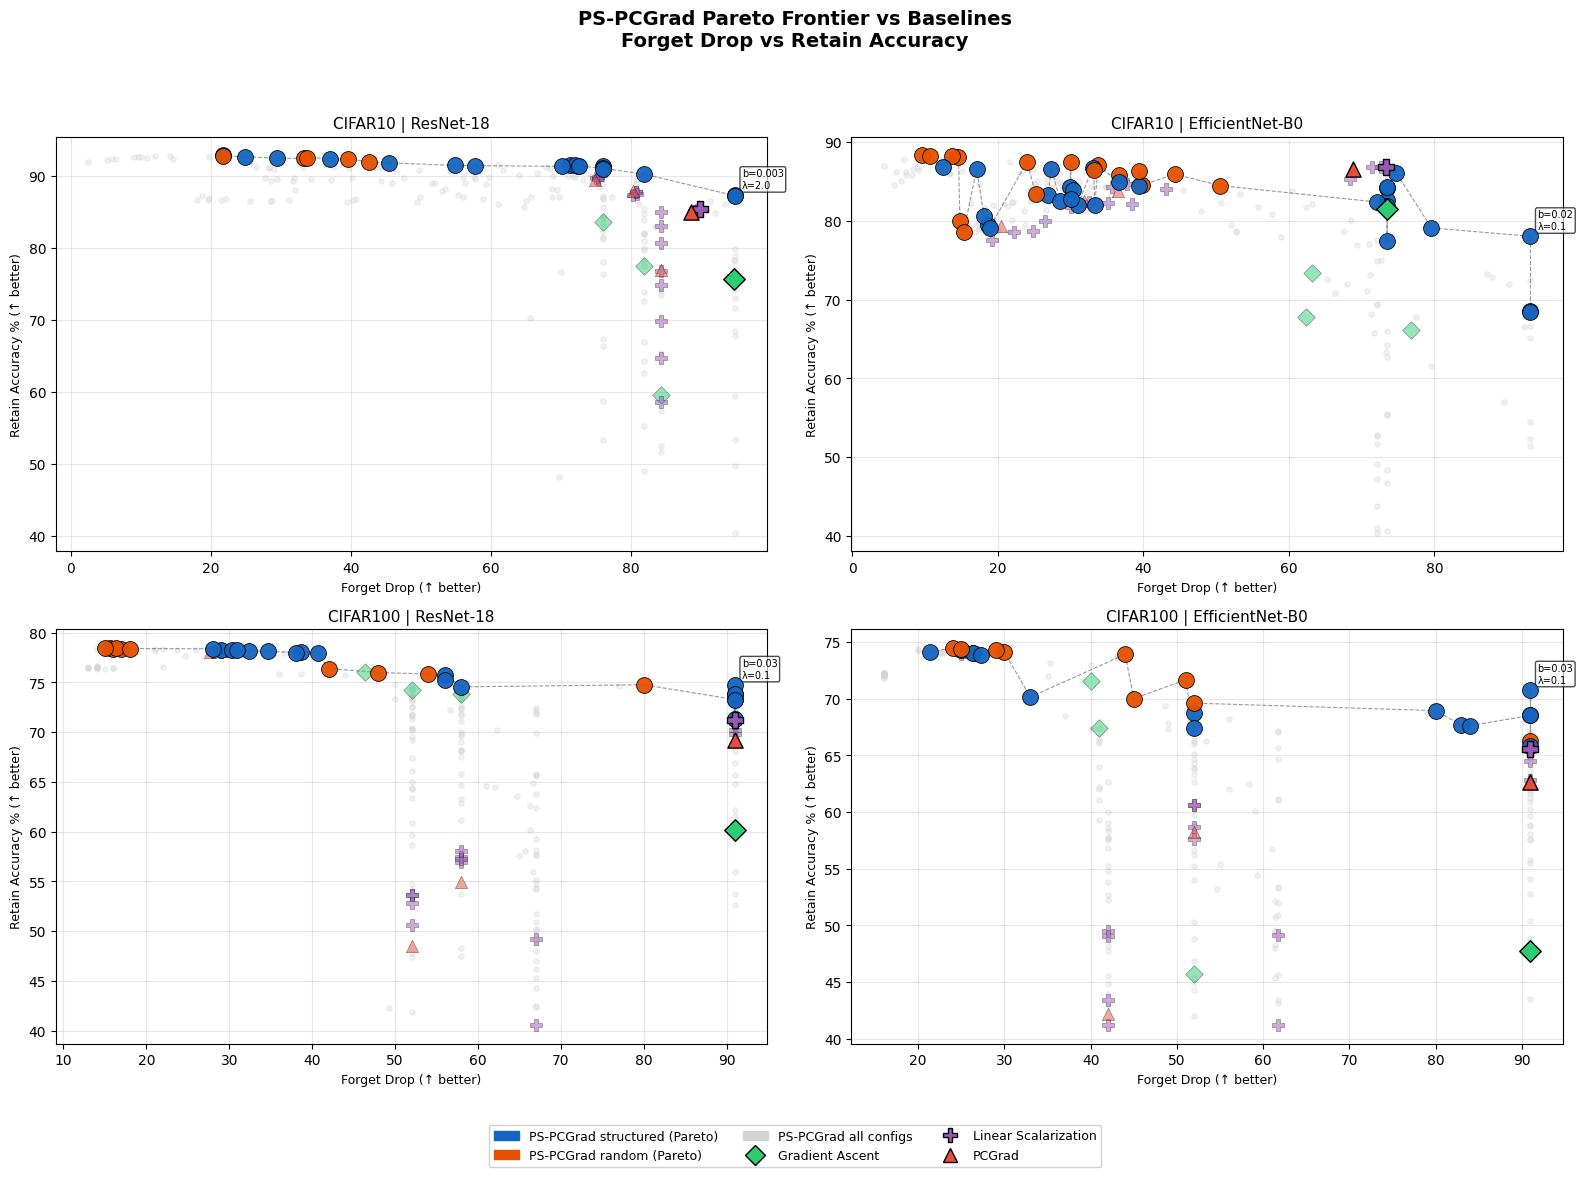

Saved pareto_2d_with_baselines.png


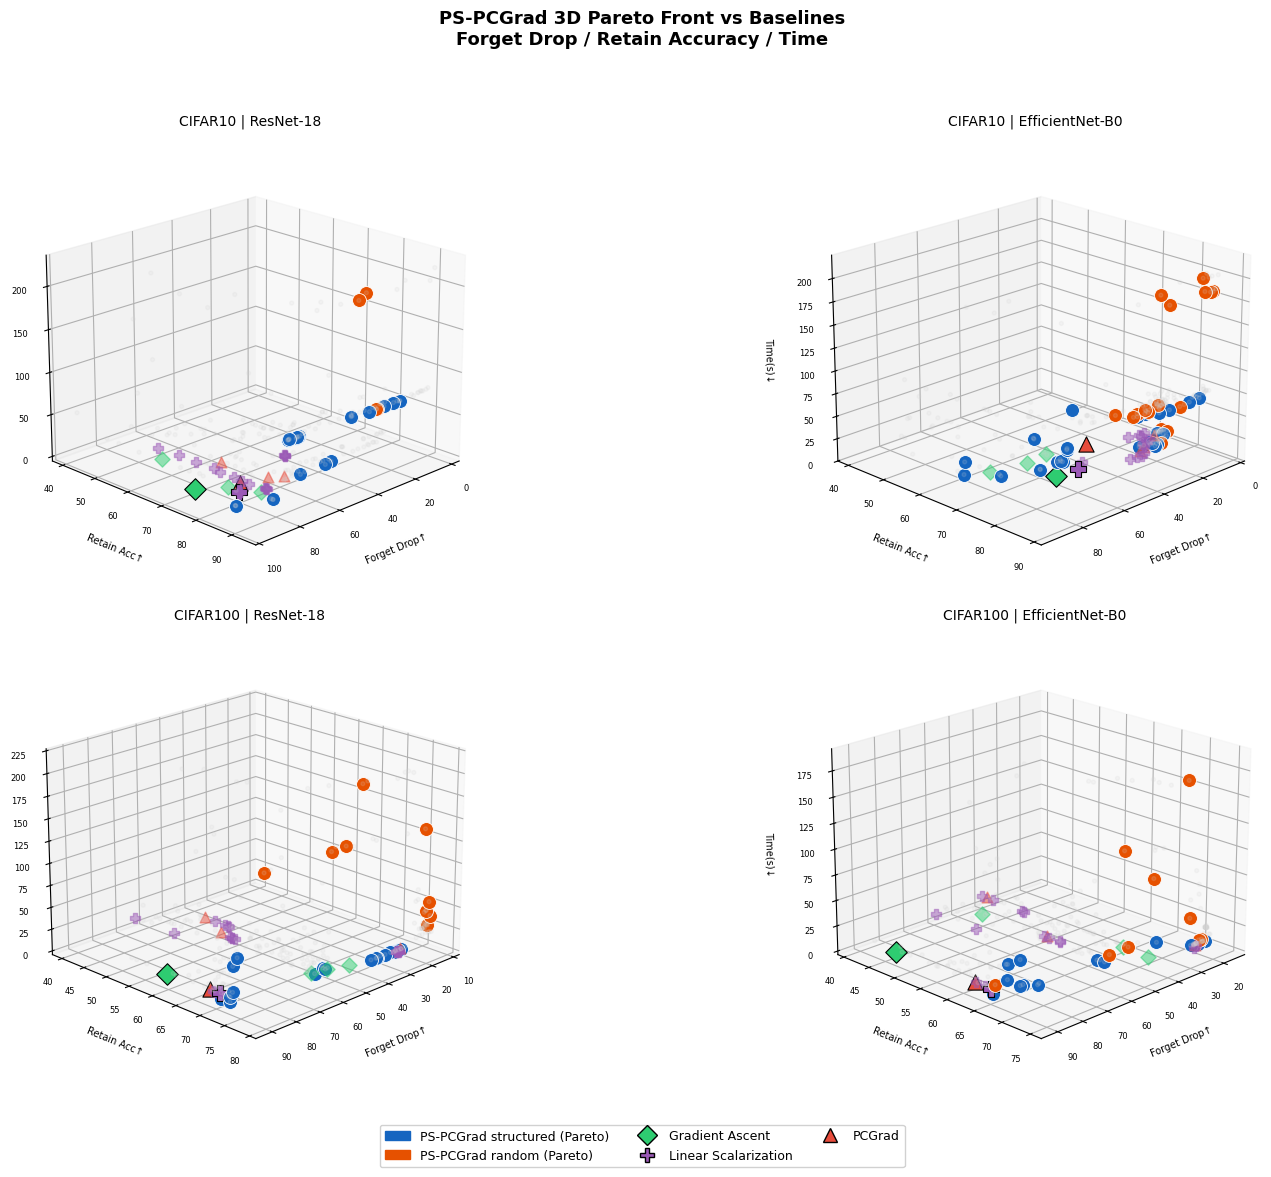

Saved pareto_3d_with_baselines.png


In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
RESULTS_FOLDER='/content/drive/MyDrive/unlearning_project/ARTIFACTS/results'
df = pd.read_csv('/content/drive/MyDrive/unlearning_project/ARTIFACTS/ablation_combined_final.csv')
for c in ['forget_drop','retain_acc','score','time_s','forget_acc']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

ps       = df[df['method']=='PS-PCGrad'].dropna(subset=['forget_drop','retain_acc','score','time_s']).copy()
baselines= df[df['method'].isin(['GradientAscent','LinearScalar','PCGrad'])].dropna(subset=['forget_drop','retain_acc']).copy()

def is_pareto(costs):
    n = costs.shape[0]
    dominated = np.zeros(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i == j: continue
            if np.all(costs[j] <= costs[i]) and np.any(costs[j] < costs[i]):
                dominated[i] = True
                break
    return ~dominated

def get_pareto_front(grp):
    costs = np.column_stack([
        -grp['forget_drop'].values,
        -grp['retain_acc'].values,
         grp['time_s'].values
    ])
    return grp[is_pareto(costs)]

# ── Visual encodings ──────────────────────────────────────────
ps_colors   = {'structured': '#1565C0', 'random': '#E65100'}
base_styles = {
    'GradientAscent': {'color': '#2ECC71', 'marker': 'D', 'label': 'Gradient Ascent',   'size': 120},
    'LinearScalar':   {'color': '#9B59B6', 'marker': 'P', 'label': 'Linear Scalarization','size': 120},
    'PCGrad':         {'color': '#E74C3C', 'marker': '^', 'label': 'PCGrad',             'size': 120},
}

combos = [
    ('CIFAR10',  'ResNet-18'),
    ('CIFAR10',  'EfficientNet-B0'),
    ('CIFAR100', 'ResNet-18'),
    ('CIFAR100', 'EfficientNet-B0'),
]

# ── PLOT 1: 2D Pareto — Forget Drop vs Retain ─────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    'PS-PCGrad Pareto Frontier vs Baselines\nForget Drop vs Retain Accuracy',
    fontsize=14, fontweight='bold')

for ax, (ds, arch) in zip(axes.flatten(), combos):
    ps_grp   = ps[(ps['data_set']==ds) & (ps['arch']==arch)]
    base_grp = baselines[(baselines['data_set']==ds) & (baselines['arch']==arch)]
    front    = get_pareto_front(ps_grp)

    # Grey background — all PS-PCGrad configs
    ax.scatter(ps_grp['forget_drop'], ps_grp['retain_acc'],
               c='lightgrey', s=15, alpha=0.3, zorder=1)

    # PS-PCGrad Pareto front
    for _, r in front.iterrows():
        c = ps_colors.get(r['mask_mode'], 'grey')
        ax.scatter(r['forget_drop'], r['retain_acc'],
                   c=c, s=130, edgecolors='black', linewidths=0.6,
                   zorder=4, alpha=0.95)

    # Pareto frontier line
    front_s = front.sort_values('forget_drop')
    ax.plot(front_s['forget_drop'], front_s['retain_acc'],
            'k--', linewidth=0.8, alpha=0.4, zorder=2)

    # Baselines — best result per method
    for method, style in base_styles.items():
        sub = base_grp[base_grp['method']==method].dropna(subset=['forget_drop','retain_acc'])
        if len(sub) == 0: continue
        # plot all baseline points smaller
        ax.scatter(sub['forget_drop'], sub['retain_acc'],
                   c=style['color'], marker=style['marker'],
                   s=80, alpha=0.5, zorder=3, edgecolors='black', linewidths=0.4)
        # highlight best baseline point
        best = sub.loc[sub['score'].idxmax()]
        ax.scatter(best['forget_drop'], best['retain_acc'],
                   c=style['color'], marker=style['marker'],
                   s=style['size'], alpha=1.0, zorder=5,
                   edgecolors='black', linewidths=1.0)

    # Annotate best PS-PCGrad point
    if len(front) > 0:
        best_ps = front.loc[front['score'].idxmax()]
        ax.annotate(f"b={best_ps['budget_b']}\nλ={best_ps['lambda']}",
                    xy=(best_ps['forget_drop'], best_ps['retain_acc']),
                    xytext=(5, 5), textcoords='offset points', fontsize=7,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

    ax.set_title(f'{ds} | {arch}', fontsize=11)
    ax.set_xlabel('Forget Drop (↑ better)', fontsize=9)
    ax.set_ylabel('Retain Accuracy % (↑ better)', fontsize=9)
    ax.grid(True, alpha=0.3)

# Legend
ps_struct = mpatches.Patch(color='#1565C0', label='PS-PCGrad structured (Pareto)')
ps_rand   = mpatches.Patch(color='#E65100', label='PS-PCGrad random (Pareto)')
ps_grey   = mpatches.Patch(color='lightgrey', label='PS-PCGrad all configs')
base_handles = [
    mlines.Line2D([],[],marker=s['marker'], color='w',
                  markerfacecolor=s['color'], markeredgecolor='black',
                  markersize=10, label=s['label'])
    for s in base_styles.values()
]
fig.legend(handles=[ps_struct, ps_rand, ps_grey] + base_handles,
           loc='lower center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, 0.01), framealpha=0.9)

plt.tight_layout(rect=[0, 0.07, 1, 0.95])
plt.savefig(f'{RESULTS_FOLDER}/pareto_2d_with_baselines.png', dpi=180, bbox_inches='tight')
plt.show()
print("Saved pareto_2d_with_baselines.png")


# ── PLOT 2: 3D Pareto — Forget Drop / Retain / Time ──────────
fig3d = plt.figure(figsize=(18, 12))
fig3d.suptitle(
    'PS-PCGrad 3D Pareto Front vs Baselines\nForget Drop / Retain Accuracy / Time',
    fontsize=13, fontweight='bold')

for idx, (ds, arch) in enumerate(combos):
    ax = fig3d.add_subplot(2, 2, idx+1, projection='3d')
    ps_grp   = ps[(ps['data_set']==ds) & (ps['arch']==arch)]
    base_grp = baselines[(baselines['data_set']==ds) & (baselines['arch']==arch)]
    front    = get_pareto_front(ps_grp)

    # Grey background
    ax.scatter(ps_grp['forget_drop'], ps_grp['retain_acc'], ps_grp['time_s'],
               c='lightgrey', s=8, alpha=0.15, depthshade=True)

    # PS-PCGrad Pareto front
    for _, r in front.iterrows():
        c = ps_colors.get(r['mask_mode'], 'grey')
        ax.scatter(r['forget_drop'], r['retain_acc'], r['time_s'],
                   c=c, s=100, edgecolors='white', linewidths=0.6,
                   zorder=5, depthshade=False)

    # Baselines — best per method
    for method, style in base_styles.items():
        sub = base_grp[base_grp['method']==method].dropna(
            subset=['forget_drop','retain_acc','time_s'])
        if len(sub) == 0: continue
        # all baseline points
        ax.scatter(sub['forget_drop'], sub['retain_acc'], sub['time_s'],
                   c=style['color'], marker=style['marker'],
                   s=60, alpha=0.5, depthshade=False)
        # best baseline
        best = sub.loc[sub['score'].idxmax()]
        ax.scatter(best['forget_drop'], best['retain_acc'], best['time_s'],
                   c=style['color'], marker=style['marker'],
                   s=style['size'], alpha=1.0, depthshade=False,
                   edgecolors='black', linewidths=0.8)

    ax.set_xlabel('Forget Drop↑', fontsize=7, labelpad=6)
    ax.set_ylabel('Retain Acc↑',  fontsize=7, labelpad=6)
    ax.set_zlabel('Time(s)↓',     fontsize=7, labelpad=6)
    ax.set_title(f'{ds} | {arch}', fontsize=10, pad=10)
    ax.tick_params(labelsize=6)
    ax.view_init(elev=20, azim=45)

# Legend
ps_handles = [
    mpatches.Patch(color='#1565C0', label='PS-PCGrad structured (Pareto)'),
    mpatches.Patch(color='#E65100', label='PS-PCGrad random (Pareto)'),
]
fig3d.legend(
    handles=ps_handles + base_handles,
    loc='lower center', ncol=3, fontsize=9,
    bbox_to_anchor=(0.5, 0.01), framealpha=0.9)

plt.tight_layout(rect=[0, 0.07, 1, 0.95])
plt.savefig(f'{RESULTS_FOLDER}/pareto_3d_with_baselines.png', dpi=180, bbox_inches='tight')
plt.show()
print("Saved pareto_3d_with_baselines.png")